# DS Automation Assignment

Using our either our original churn data from week 1 or our prepped churn data from week 2:
- use pycaret or TPOT find an ML algorithm that performs best on the data
    - Choose a metric you think is best to use for finding the best model; by default, it is accuracy but it could be AUC, precision, recall, etc. The week 3 FTE has some information on these different metrics.
- save the model to disk
- create a Python script/file/module with a function that takes a pandas dataframe as an input and returns the probability of churn for each row in the dataframe
    - your Python file/function should print out the predictions for new data (new_churn_data.csv)
    - the true values for the new data are [1, 0, 0, 1, 0] if you're interested
- test your Python module and function with the new data, new_churn_data.csv
- upload this Jupyter Notebook and Python file and requirements.txt files to a GitHub repository
- write a short summary of the process and results in your GitHub README.md file.
- turn in a link to the repository in the week 5 assignment dropbox.

*Optional* challenges:
- return the probability of churn for each new prediction, and the percentile where that prediction is in the distribution of probability predictions from the training dataset (e.g. a high probability of churn like 0.78 might be at the 90th percentile)
- use other autoML packages, such as H2O, MLBox, etc, and compare performance and features with pycaret
- create a class in your Python module to hold the functions that you created
- accept user input to specify a file using a tool such as Python's `input()` function, the `click` package for command-line arguments, or a GUI
- Use the unmodified churn data (new_unmodified_churn_data.csv) in your Python script. This will require adding the same preprocessing steps from week 2 since this data is like the original unmodified dataset from week 1.

In [41]:
import pandas as pd

df = pd.read_csv("prepped_churn_data.csv")
df.head()

,Unnamed: 0,customerID,tenure,PhoneService,Contract,PaymentMethod,MonthlyCharges,TotalCharges,Churn,MonthlyToTotal_Ratio,Tenure_to_TotalCharges_Ratio,Log_TotalCharges
0,0,7590-VHVEG,1,0,0,0,29.85,29.85,No,0.967585,0.032415,3.429137
1,1,5575-GNVDE,34,1,1,1,56.95,1889.50,No,0.030124,0.017985,7.544597
2,2,3668-QPYBK,2,1,0,1,53.85,108.15,Yes,0.493358,0.018323,4.692723
3,3,7795-CFOCW,45,0,1,2,42.30,1840.75,No,0.022967,0.024433,7.518471
4,4,9237-HQITU,2,1,0,0,70.70,151.65,Yes,0.463151,0.013102,5.028148


In [42]:
from pycaret.classification import ClassificationExperiment
from pycaret.classification import load_model, predict_model


In [43]:
automl = ClassificationExperiment() 

In [44]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 12 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   Unnamed: 0                    7043 non-null   int64  
 1   customerID                    7043 non-null   object 
 2   tenure                        7043 non-null   int64  
 3   PhoneService                  7043 non-null   int64  
 4   Contract                      7043 non-null   int64  
 5   PaymentMethod                 7043 non-null   int64  
 6   MonthlyCharges                7043 non-null   float64
 7   TotalCharges                  7032 non-null   float64
 8   Churn                         7043 non-null   object 
 9   MonthlyToTotal_Ratio          7032 non-null   float64
 10  Tenure_to_TotalCharges_Ratio  7032 non-null   float64
 11  Log_TotalCharges              7032 non-null   float64
dtypes: float64(5), int64(5), object(2)
memory usage: 660.4+ KB


In [45]:
automl.setup(df, target='Churn')

,Description,Value
0,Session id,406
1,Target,Churn
2,Target type,Binary
3,Target mapping,"No: 0, Yes: 1"
4,Original data shape,"(7043, 12)"
5,Transformed data shape,"(7043, 12)"
6,Transformed train set shape,"(4930, 12)"
7,Transformed test set shape,"(2113, 12)"
8,Numeric features,10
9,Categorical features,1


In [46]:
automl

In [47]:
best_model = automl.compare_models()

,Model,Accuracy,AUC,Recall,Prec.,F1,Kappa,MCC,TT (Sec)
nb,Naive Bayes,0.7639,0.8008,0.7639,0.7683,0.7657,0.4046,0.4051,0.0180
lr,Logistic Regression,0.7631,0.8114,0.7631,0.7426,0.7235,0.2495,0.2899,0.3060
dt,Decision Tree Classifier,0.7347,0.5000,0.7347,0.5398,0.6223,0.0000,0.0000,0.0210
ridge,Ridge Classifier,0.7347,0.8381,0.7347,0.5398,0.6223,0.0000,0.0000,0.0170
rf,Random Forest Classifier,0.7347,0.6615,0.7347,0.5398,0.6223,0.0000,0.0000,0.0800
qda,Quadratic Discriminant Analysis,0.7347,0.5546,0.7347,0.5398,0.6223,0.0000,0.0000,0.0150
ada,Ada Boost Classifier,0.7347,0.5000,0.7347,0.5398,0.6223,0.0000,0.0000,0.0150
gbc,Gradient Boosting Classifier,0.7347,0.5000,0.7347,0.5398,0.6223,0.0000,0.0000,0.1120
lda,Linear Discriminant Analysis,0.7347,0.5000,0.7347,0.5398,0.6223,0.0000,0.0000,0.0150
et,Extra Trees Classifier,0.7347,0.7268,0.7347,0.5398,0.6223,0.0000,0.0000,0.0530


In [48]:
best_model

GaussianNB(priors=None, var_smoothing=1e-09)

In [49]:
automl.evaluate_model(best_model)

interactive(children=(ToggleButtons(description='Plot Type:', icons=('',), options=(('Pipeline Plot', 'pipelin…

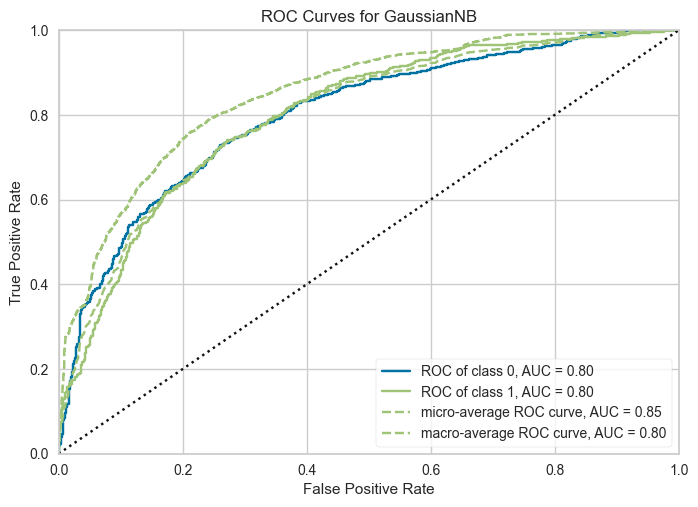

In [50]:
automl.plot_model(best_model)

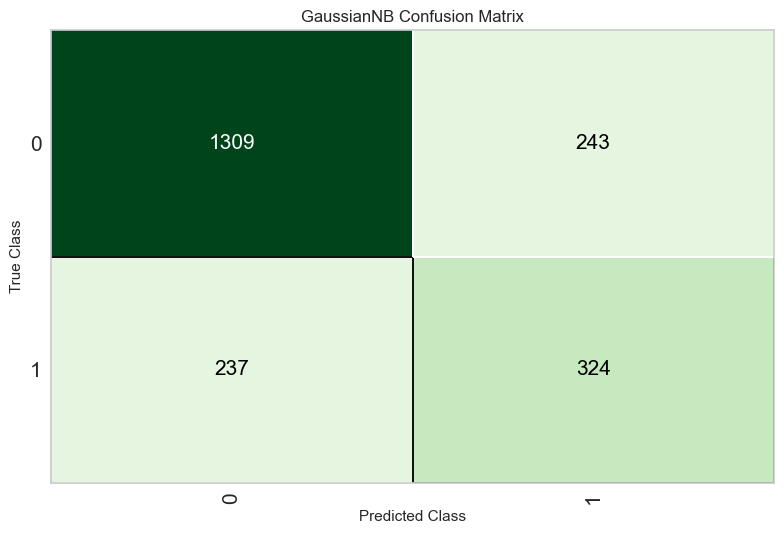

In [51]:
automl.plot_model(best_model, plot = 'confusion_matrix')

In [52]:
df.iloc[-2:-1].shape

(1, 12)

In [53]:
automl.predict_model(best_model, df.iloc[-2:-1])

,Model,Accuracy,AUC,Recall,Prec.,F1,Kappa,MCC
0,Naive Bayes,1.0000,0,1.0000,1.0000,1.0000,nan,0.0000


,Unnamed: 0,customerID,tenure,PhoneService,Contract,PaymentMethod,MonthlyCharges,TotalCharges,MonthlyToTotal_Ratio,Tenure_to_TotalCharges_Ratio,Log_TotalCharges,Churn,prediction_label,prediction_score
7041,7041,8361-LTMKD,4,1,0,1,74.400002,306.600006,0.241873,0.013004,5.7288,Yes,Yes,0.9688


In [54]:
automl.save_model(best_model, 'pycaret_model')

Transformation Pipeline and Model Successfully Saved


(Pipeline(memory=Memory(location=None),
          steps=[('label_encoding',
                  TransformerWrapperWithInverse(exclude=None, include=None,
                                                transformer=LabelEncoder())),
                 ('numerical_imputer',
                  TransformerWrapper(exclude=None,
                                     include=['Unnamed: 0', 'tenure',
                                              'PhoneService', 'Contract',
                                              'PaymentMethod', 'MonthlyCharges',
                                              'TotalCharges',
                                              'MonthlyToTotal_Ratio',
                                              'Tenure_to_TotalCharge...
                                                               drop_invariant=False,
                                                               handle_missing='return_nan',
                                                               handle_unkn

In [55]:
new_pycaret = ClassificationExperiment()
loaded_model = new_pycaret.load_model('pycaret_model')

Transformation Pipeline and Model Successfully Loaded


In [56]:
new_pycaret.predict_model(loaded_model, df.iloc[-2:-1])

,Unnamed: 0,customerID,tenure,PhoneService,Contract,PaymentMethod,MonthlyCharges,TotalCharges,MonthlyToTotal_Ratio,Tenure_to_TotalCharges_Ratio,Log_TotalCharges,Churn,prediction_label,prediction_score
7041,7041,8361-LTMKD,4,1,0,1,74.400002,306.600006,0.241873,0.013004,5.7288,Yes,Yes,0.9688


In [57]:
from IPython.display import Code

Code('new_churn_data.py')

import pandas as pd
import pickle
from pycaret.classification import load_model, predict_model


def load_data(filepath):

    df = pd.read_csv(filepath)
    return df


def make_predictions(df):
   
    model = load_model("pycaret_model")
    predictions = predict_model(model, data=df)
    return predictions


if __name__ == "__main__":
    df = load_data('new_churn_data.csv')
    predictions = make_predictions(df)
    print('predictions:')
    print(predictions)

In [58]:
from pycaret.classification import setup, compare_models, save_model

s = setup(data=df, target='Churn', ignore_features=['columns_you_dont_have'])
model = compare_models()
save_model(model, 'pycaret_model_simplified')

,Description,Value
0,Session id,3089
1,Target,Churn
2,Target type,Binary
3,Target mapping,"No: 0, Yes: 1"
4,Original data shape,"(7043, 12)"
5,Transformed data shape,"(7043, 12)"
6,Transformed train set shape,"(4930, 12)"
7,Transformed test set shape,"(2113, 12)"
8,Ignore features,1
9,Numeric features,10


,Model,Accuracy,AUC,Recall,Prec.,F1,Kappa,MCC,TT (Sec)
nb,Naive Bayes,0.7684,0.8006,0.7684,0.7719,0.7696,0.4132,0.4141,0.0140
lr,Logistic Regression,0.7542,0.8075,0.7542,0.7290,0.6997,0.1873,0.2352,0.0500
dt,Decision Tree Classifier,0.7347,0.5000,0.7347,0.5398,0.6223,0.0000,0.0000,0.0170
ridge,Ridge Classifier,0.7347,0.8378,0.7347,0.5398,0.6223,0.0000,0.0000,0.0140
rf,Random Forest Classifier,0.7347,0.7082,0.7347,0.5398,0.6223,0.0000,0.0000,0.0840
qda,Quadratic Discriminant Analysis,0.7347,0.5202,0.7347,0.5398,0.6223,0.0000,0.0000,0.0160
ada,Ada Boost Classifier,0.7347,0.5000,0.7347,0.5398,0.6223,0.0000,0.0000,0.0200
gbc,Gradient Boosting Classifier,0.7347,0.5000,0.7347,0.5398,0.6223,0.0000,0.0000,0.1070
lda,Linear Discriminant Analysis,0.7347,0.5000,0.7347,0.5398,0.6223,0.0000,0.0000,0.0170
et,Extra Trees Classifier,0.7347,0.6267,0.7347,0.5398,0.6223,0.0000,0.0000,0.0530


Transformation Pipeline and Model Successfully Saved


(Pipeline(memory=Memory(location=None),
          steps=[('label_encoding',
                  TransformerWrapperWithInverse(exclude=None, include=None,
                                                transformer=LabelEncoder())),
                 ('numerical_imputer',
                  TransformerWrapper(exclude=None,
                                     include=['Unnamed: 0', 'tenure',
                                              'PhoneService', 'Contract',
                                              'PaymentMethod', 'MonthlyCharges',
                                              'TotalCharges',
                                              'MonthlyToTotal_Ratio',
                                              'Tenure_to_TotalCharge...
                                                               drop_invariant=False,
                                                               handle_missing='return_nan',
                                                               handle_unkn

In [34]:
import pandas as pd
from pycaret.classification import load_model

model = load_model("pycaret_model")

# This shows the columns the model expects BEFORE engineering
model_input_cols = model[0].feature_names_in_
model_input_cols

Transformation Pipeline and Model Successfully Loaded


['Unnamed: 0',
 'customerID',
 'tenure',
 'PhoneService',
 'Contract',
 'PaymentMethod',
 'MonthlyCharges',
 'TotalCharges',
 'MonthlyToTotal_Ratio',
 'Tenure_to_TotalCharges_Ratio',
 'Log_TotalCharges',
 'Churn']

In [61]:
df_new = pd.read_csv("new_churn_data.csv")
df_new.columns

Index(['customerID', 'tenure', 'PhoneService', 'Contract', 'PaymentMethod',
       'MonthlyCharges', 'TotalCharges', 'charge_per_tenure'],
      dtype='object')

In [66]:
new_df = pd.read_csv("new_churn_data.csv")
new_df.columns.tolist()

['customerID',
 'tenure',
 'PhoneService',
 'Contract',
 'PaymentMethod',
 'MonthlyCharges',
 'TotalCharges',
 'charge_per_tenure']

In [67]:
import pandas as pd
from pycaret.classification import setup, compare_models, save_model

# Load your original training dataset
training_df = pd.read_csv("prepped_churn_data.csv")

# Columns that appear in BOTH datasets
keep_cols = [
    'customerID',
    'tenure',
    'PhoneService',
    'Contract',
    'PaymentMethod',
    'MonthlyCharges',
    'TotalCharges',
    'Churn'   # keep the target for training
]

training_df_simplified = training_df[keep_cols]

# Train a new model using only the overlapping columns
s = setup(
    data=training_df_simplified,
    target='Churn',
    session_id=123
)

model = compare_models()
save_model(model, 'pycaret_model_simplified')

,Description,Value
0,Session id,123
1,Target,Churn
2,Target type,Binary
3,Target mapping,"No: 0, Yes: 1"
4,Original data shape,"(7043, 8)"
5,Transformed data shape,"(7043, 8)"
6,Transformed train set shape,"(4930, 8)"
7,Transformed test set shape,"(2113, 8)"
8,Numeric features,6
9,Categorical features,1


,Model,Accuracy,AUC,Recall,Prec.,F1,Kappa,MCC,TT (Sec)
nb,Naive Bayes,0.7680,0.8094,0.7680,0.7813,0.7730,0.4336,0.4363,0.0150
knn,K Neighbors Classifier,0.7659,0.7429,0.7659,0.7507,0.7544,0.3485,0.3545,0.0270
dt,Decision Tree Classifier,0.7347,0.5000,0.7347,0.5398,0.6223,0.0000,0.0000,0.0150
ridge,Ridge Classifier,0.7347,0.8222,0.7347,0.5398,0.6223,0.0000,0.0000,0.0170
rf,Random Forest Classifier,0.7347,0.6550,0.7347,0.5398,0.6223,0.0000,0.0000,0.0790
qda,Quadratic Discriminant Analysis,0.7347,0.5000,0.7347,0.5398,0.6223,0.0000,0.0000,0.0160
ada,Ada Boost Classifier,0.7347,0.5000,0.7347,0.5398,0.6223,0.0000,0.0000,0.0150
gbc,Gradient Boosting Classifier,0.7347,0.5038,0.7347,0.5398,0.6223,0.0000,0.0000,0.0600
lda,Linear Discriminant Analysis,0.7347,0.5000,0.7347,0.5398,0.6223,0.0000,0.0000,0.0170
et,Extra Trees Classifier,0.7347,0.6065,0.7347,0.5398,0.6223,0.0000,0.0000,0.0630


Transformation Pipeline and Model Successfully Saved


(Pipeline(memory=Memory(location=None),
          steps=[('label_encoding',
                  TransformerWrapperWithInverse(exclude=None, include=None,
                                                transformer=LabelEncoder())),
                 ('numerical_imputer',
                  TransformerWrapper(exclude=None,
                                     include=['tenure', 'PhoneService',
                                              'Contract', 'PaymentMethod',
                                              'MonthlyCharges', 'TotalCharges'],
                                     transformer=SimpleImputer(add_indicator=False,
                                                               copy=True,...
                                                               strategy='most_frequent'))),
                 ('rest_encoding',
                  TransformerWrapper(exclude=None, include=['customerID'],
                                     transformer=TargetEncoder(cols=['customerID'],
     

In [65]:
import pandas as pd

training_df = pd.read_csv("prepped_churn_data.csv")
training_df.columns.tolist()

['Unnamed: 0',
 'customerID',
 'tenure',
 'PhoneService',
 'Contract',
 'PaymentMethod',
 'MonthlyCharges',
 'TotalCharges',
 'Churn',
 'MonthlyToTotal_Ratio',
 'Tenure_to_TotalCharges_Ratio',
 'Log_TotalCharges']

In [68]:
%run new_churn_data.py

Transformation Pipeline and Model Successfully Loaded


predictions:
   customerID  tenure  PhoneService  Contract  PaymentMethod  MonthlyCharges  \
0  9305-CKSKC      22             1         0              2       97.400002   
1  1452-KNGVK       8             0         1              1       77.300003   
2  6723-OKKJM      28             1         0              0       28.250000   
3  7832-POPKP      62             1         0              2      101.699997   
4  6348-TACGU      10             0         0              1       51.150002   

   TotalCharges  charge_per_tenure prediction_label  prediction_score  
0    811.700012          36.895454               No            0.5535  
1   1701.949951         212.743744               No            0.9396  
2    250.899994           8.960714               No            0.5494  
3   3106.560059          50.105808               No            0.9527  
4   3440.969971         344.096985               No            0.7597  
